In [1]:
# Bibliotecas básicas para tratamento de dados
import yfinance as yf
import pandas as pd
import numpy as np

# Bibliotecas para análise exploratória
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Bibliotecas para modelos preditivos
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
import pmdarima as pm


In [2]:
periodo = 3

In [3]:
dados = yf.download('^BVSP', period=f'{periodo}y')
dados.head()

C:\Users\sbagn\AppData\Local\Temp\ipykernel_21180\494084240.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download('^BVSP', period=f'{periodo}y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^BVSP,^BVSP,^BVSP,^BVSP,^BVSP
Date,,,,,
2022-08-26,112299.0,114091.0,111978.0,113533.0,11159700
2022-08-29,112323.0,113222.0,111689.0,112296.0,9795800
2022-08-30,110431.0,112869.0,110103.0,112323.0,11937900
2022-08-31,109523.0,111364.0,109523.0,110431.0,14791100
2022-09-01,110405.0,110405.0,108217.0,109524.0,14478000


In [4]:
dados = dados['Close'].reset_index()

In [5]:
dados.head()

Ticker,Date,^BVSP
0,2022-08-26,112299.0
1,2022-08-29,112323.0
2,2022-08-30,110431.0
3,2022-08-31,109523.0
4,2022-09-01,110405.0


In [6]:
dados = dados.rename(columns={'Date': 'data', '^BVSP': 'fechamento'})

In [7]:
dados.index = dados['data']
dados = dados.xs('fechamento', axis = 1).copy()
dados = pd.DataFrame(dados)
dados.index.name=None
dados.head()

,fechamento
2022-08-26,112299.0
2022-08-29,112323.0
2022-08-30,110431.0
2022-08-31,109523.0
2022-09-01,110405.0


In [8]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 748 entries, 2022-08-26 to 2025-08-26
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fechamento  748 non-null    float64
dtypes: float64(1)
memory usage: 11.7 KB


In [9]:
teste_adf = adfuller(dados)

adf_statistic = teste_adf[0]
p_value = teste_adf[1]
critical_values = teste_adf[4]

In [10]:
def verifica_adf(df, titulo):
    teste_adf = adfuller(df)

    adf_statistic = teste_adf[0]
    p_value = teste_adf[1]
    critical_values = teste_adf[4]

    n_equals = 60
    inicio = df.index.min()
    final = df.index.max()

    print(f'{n_equals*'='}\nTeste ADF (Dickey-Fuller Aumentado)')
    print(f'Série examinada: {titulo} | Período: {periodo} anos\n{n_equals*'='}')
    print(f'Intervalo de {inicio.day}/{inicio.month}/{inicio.year} até {final.day}/{final.month}/{final.year}')
    print(f'Número de observações: {len(df)}\n{n_equals*'='}')
    print(f'\nADF Statistic: {adf_statistic:.6f}')
    print(f'p-value: {p_value:.6f}')
    print('\nValores Críticos: ')
    for key, value in critical_values.items():
        print(f'{key}: {value:.6f}')
    print(f'\n{n_equals*'='}')
    if p_value <= 0.05:
        print('Hipótese nula REJEITADA - Série ESTACIONARIA')
    else:
        print('Hipótese nula NÃO REJEITADA - série NÃO ESTACIONÁRIA')

In [11]:
verifica_adf(dados, 'Fechamento IBOVESPA')

Teste ADF (Dickey-Fuller Aumentado)
Série examinada: Fechamento IBOVESPA | Período: 3 anos
Intervalo de 26/8/2022 até 26/8/2025
Número de observações: 748

ADF Statistic: -1.511935
p-value: 0.527599

Valores Críticos: 
1%: -3.439134
5%: -2.865417
10%: -2.568834

Hipótese nula NÃO REJEITADA - série NÃO ESTACIONÁRIA


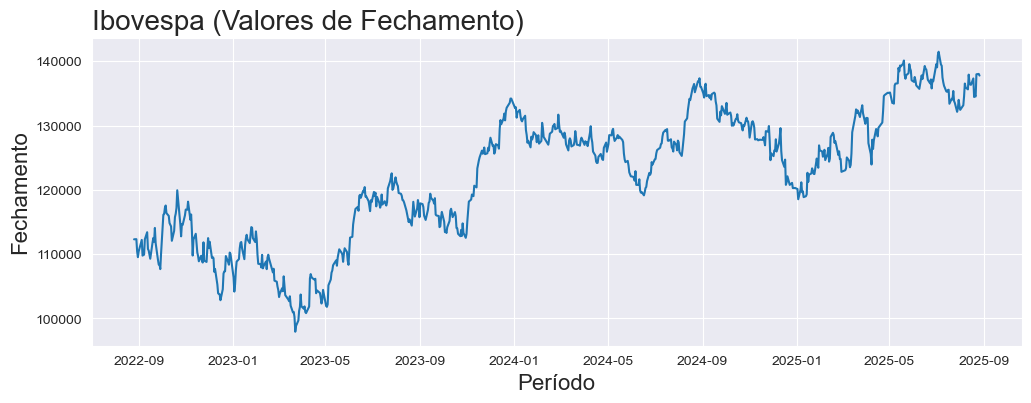

In [12]:
sns.set_style('darkgrid')

ax = sns.lineplot(x = dados.index, y = dados.fechamento)
ax.figure.set_size_inches(12,4)
ax.set_title('Ibovespa (Valores de Fechamento)', loc='left', fontsize = 20)
ax.set_xlabel('Período', fontsize = 16)
ax.set_ylabel('Fechamento', fontsize=16)
ax = ax

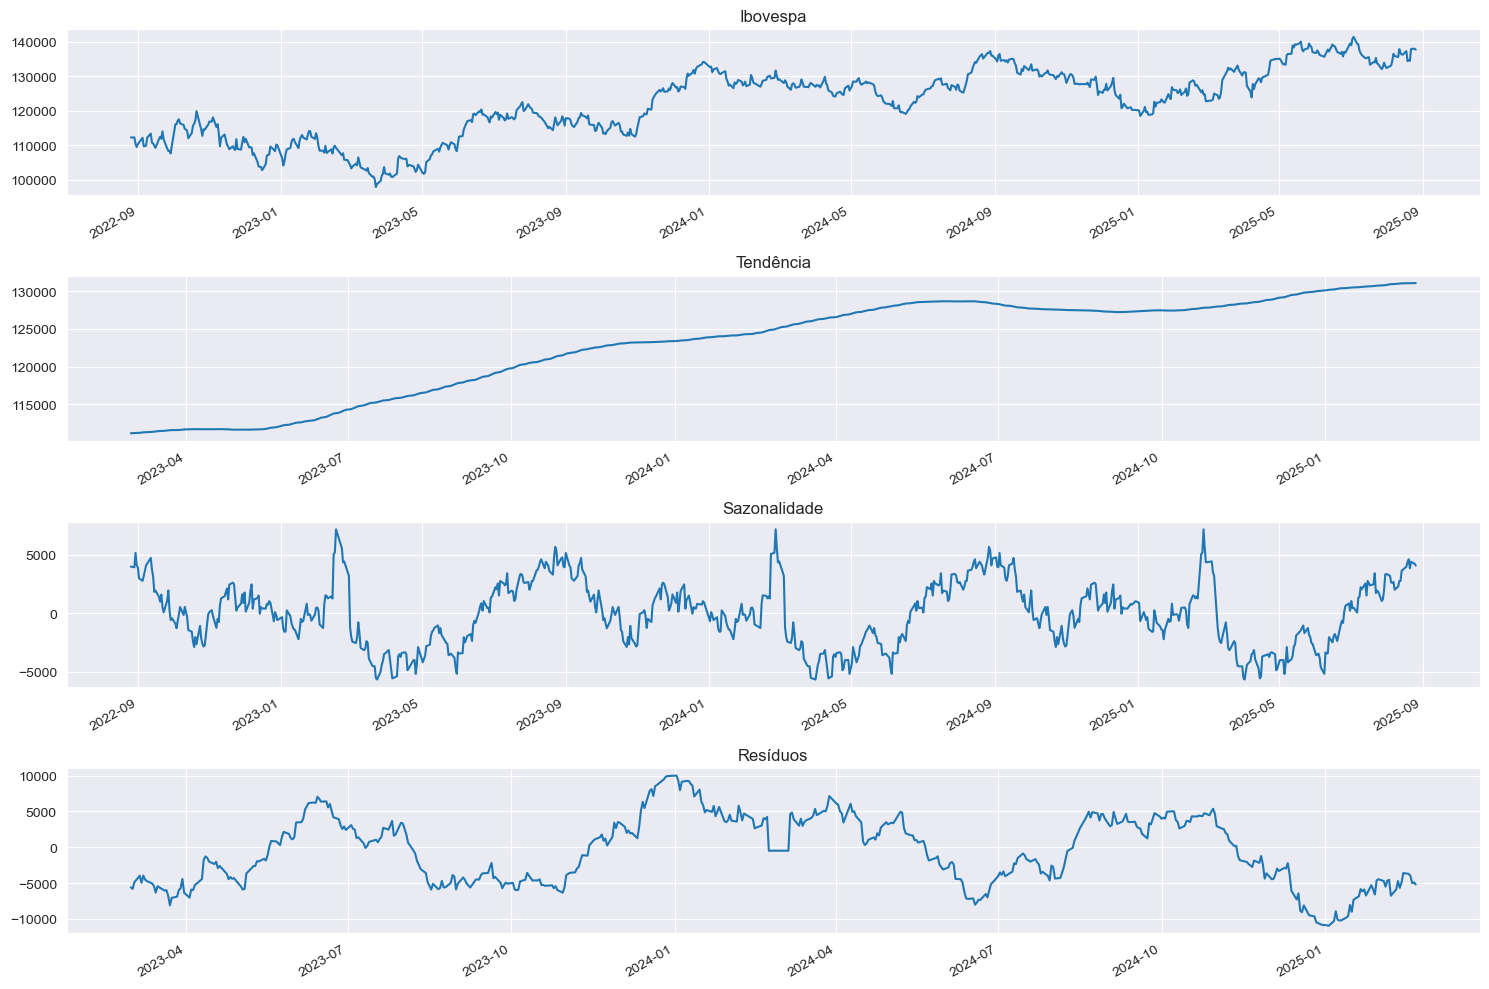

In [13]:
decomposicao_serie_temporal = seasonal_decompose(dados['fechamento'],
                                                 model = 'addtive',
                                                 period = 252)

fig, (ax1,ax2,ax3,ax4) = plt.subplots(4,1, figsize = (15,10))

decomposicao_serie_temporal.observed.plot(ax=ax1, title='Ibovespa')
decomposicao_serie_temporal.trend.plot(ax=ax2, title = 'Tendência')
decomposicao_serie_temporal.seasonal.plot(ax=ax3, title = 'Sazonalidade')
decomposicao_serie_temporal.resid.plot(ax=ax4, title = 'Resíduos')

plt.tight_layout()

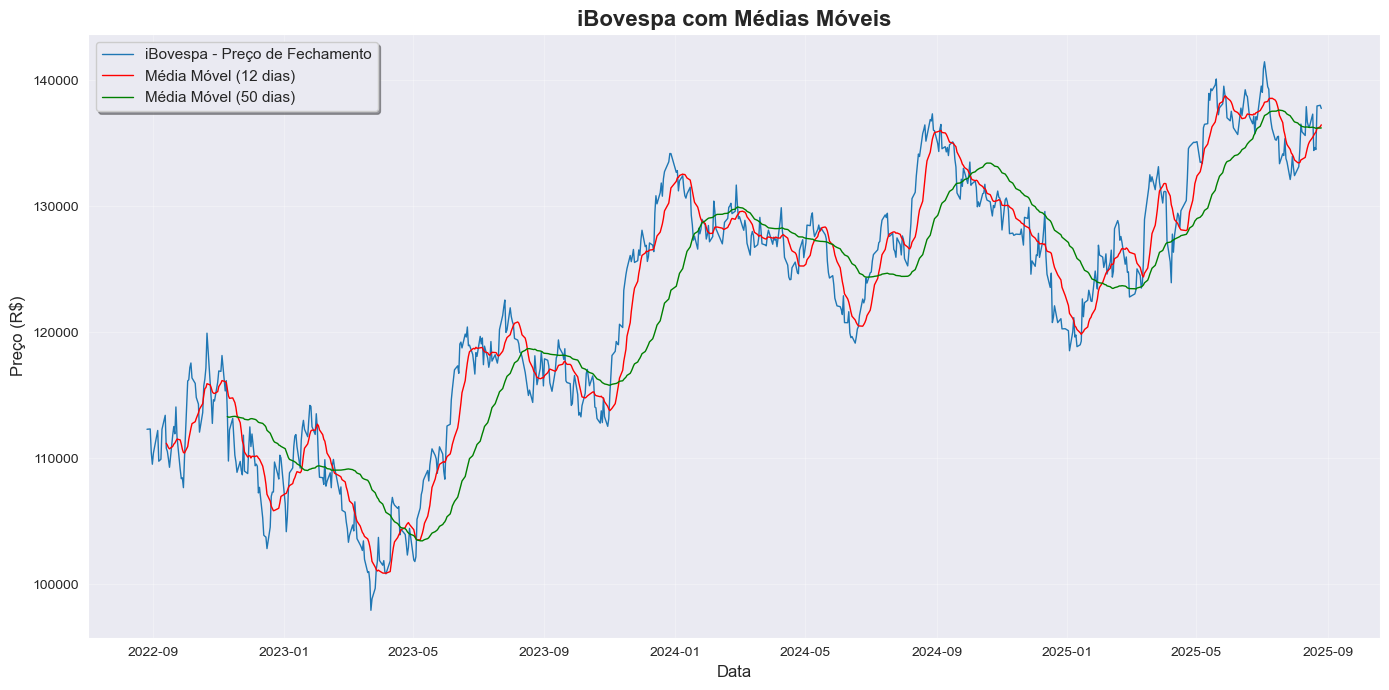

In [14]:
mm12 = dados.rolling(12).mean()
mm50 = dados.rolling(51).mean()

plt.figure(figsize=(14, 7))

plt.plot(dados.index, dados.fechamento, 
         label='iBovespa - Preço de Fechamento', 
         linewidth=1)

plt.plot(mm12.index, mm12.fechamento, 
         color='r', 
         label='Média Móvel (12 dias)', 
         linewidth=1)

plt.plot(mm50.index, mm50.fechamento, 
         color='g', 
         label='Média Móvel (50 dias)', 
         linewidth=1)


plt.legend(loc='upper left', 
           fontsize=11, 
           frameon=True, 
           fancybox=True, 
           shadow=True)

plt.title('iBovespa com Médias Móveis', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
dados_log = np.log(dados)
dados_diff = dados_log.diff().dropna()
dados_diff.head()

,fechamento
2022-08-29,0.000214
2022-08-30,-0.016988
2022-08-31,-0.008256
2022-09-01,0.008021
2022-09-02,0.004149


In [16]:
dados_diff.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 747 entries, 2022-08-29 to 2025-08-26
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fechamento  747 non-null    float64
dtypes: float64(1)
memory usage: 11.7 KB


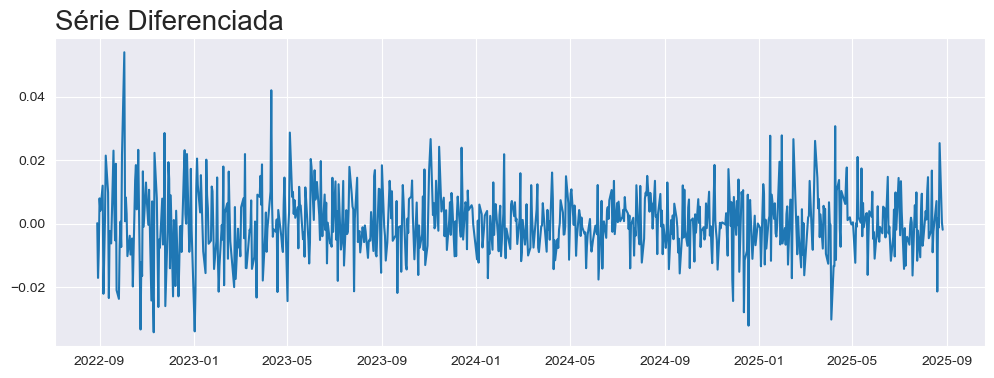

In [17]:
ax = sns.lineplot(x = dados_diff.index, y = dados_diff.fechamento)
ax.figure.set_size_inches(12,4)
ax.set_title('Série Diferenciada', loc='left', fontsize = 20)
ax.set_xlabel(None)
ax.set_ylabel(None)
ax = ax

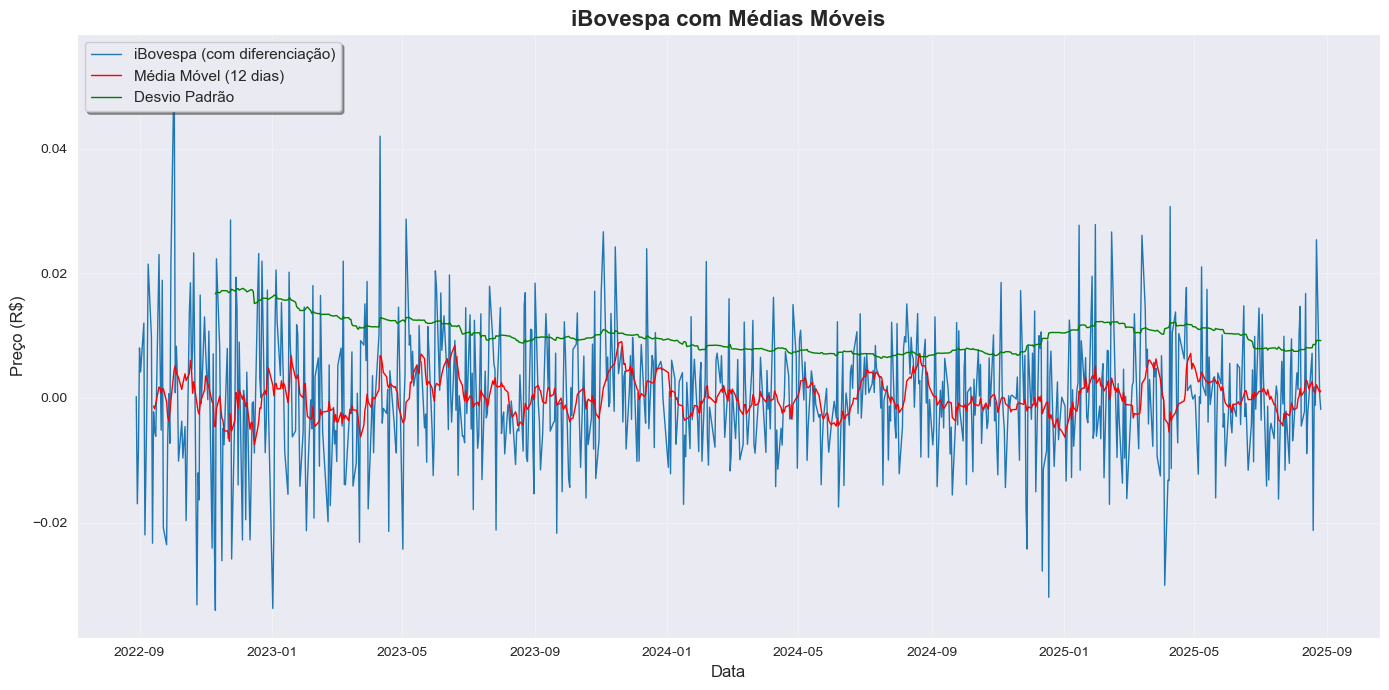

In [18]:
mm12_diff = dados_diff.rolling(12).mean()
desvio_diff = dados_diff.rolling(51).std()

plt.figure(figsize=(14, 7))

plt.plot(dados_diff.index, dados_diff.fechamento, 
         label='iBovespa (com diferenciação)', 
         linewidth=1)

plt.plot(mm12_diff.index, mm12_diff.fechamento, 
         color='r', 
         label='Média Móvel (12 dias)', 
         linewidth=1)

plt.plot(desvio_diff.index, desvio_diff.fechamento, 
         color='g', 
         label='Desvio Padrão', 
         linewidth=1)


plt.legend(loc='upper left', 
           fontsize=11, 
           frameon=True, 
           fancybox=True, 
           shadow=True)

plt.title('iBovespa com Médias Móveis', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
verifica_adf(dados_diff, 'IBOVESPA (Série diferenciada)')

Teste ADF (Dickey-Fuller Aumentado)
Série examinada: IBOVESPA (Série diferenciada) | Período: 3 anos
Intervalo de 29/8/2022 até 26/8/2025
Número de observações: 747

ADF Statistic: -27.130176
p-value: 0.000000

Valores Críticos: 
1%: -3.439146
5%: -2.865422
10%: -2.568837

Hipótese nula REJEITADA - Série ESTACIONARIA


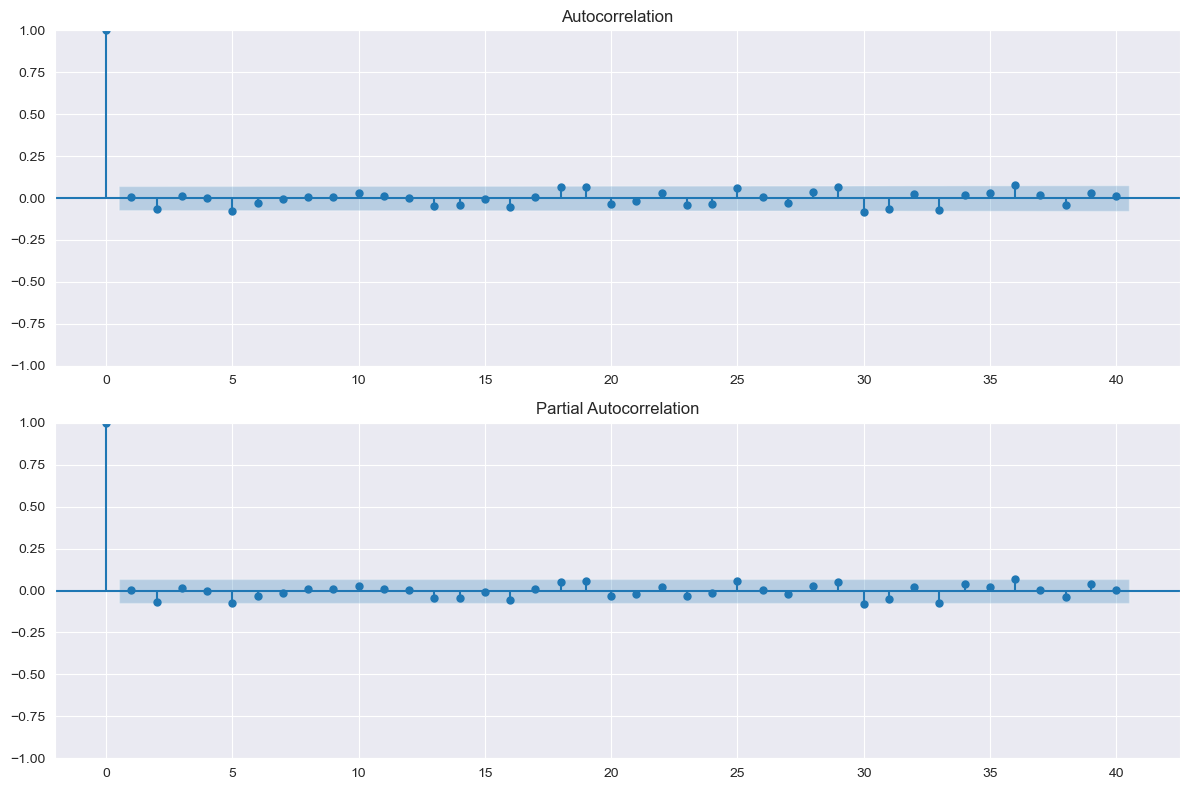

In [20]:
fig, axes = plt.subplots(2,1, figsize=(12,8))

plot_acf(dados_diff['fechamento'], ax=axes[0], lags=40, alpha=0.05)
plot_pacf(dados_diff['fechamento'], ax=axes[1], lags=40, alpha=0.05)
plt.tight_layout()
plt.show()

c:\Users\sbagn\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\sbagn\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\sbagn\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


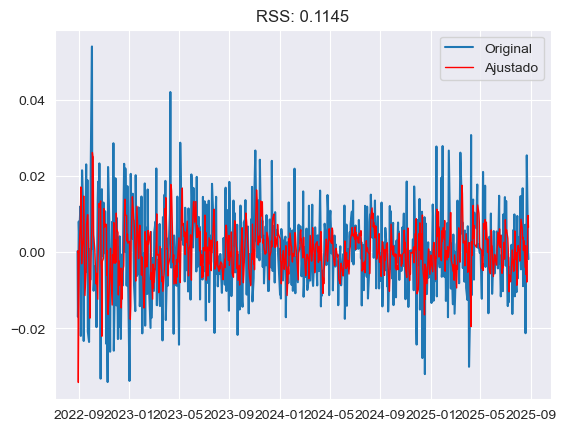

In [21]:
model = ARIMA(dados_diff, order=(2,2,1))
resultado_AR = model.fit()

plt.plot(dados_diff.index, dados_diff.values, label='Original')
plt.plot(dados_diff.index, resultado_AR.fittedvalues, color='r', label='Ajustado', linewidth=1)

rss = np.sum((resultado_AR.fittedvalues - dados_diff.fechamento)**2)
plt.title('RSS: %.4f' % rss)
plt.legend()
plt.show()

In [22]:
y_real = dados_diff.iloc[:,0]
y_pred = resultado_AR.fittedvalues

In [23]:
mse = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_real, y_pred)
mape = np.mean(np.abs((y_real - y_pred) / y_real.replace(0,np.nan))) * 100

print(f'MSE: {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nMAPE: {mape:.4f}')

MSE: 0.0002
RMSE: 0.0124
MAE: 0.0094
MAPE: 284.3390


In [24]:
n = len(dados)
serie = dados.fechamento.values
train_size = 30 #int(n * .8)

train, test = serie[:train_size], serie[train_size:]

In [25]:
auto_model = pm.auto_arima(train,
                           seasonal = False,
                           stepwise = True,
                           trace = True,
                           error_action = 'ignore',
                           suppress_warnings = True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=784.607, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=766.760, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=549.521, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=550.106, Time=0.14 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=549.959, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=764.422, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=538.762, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=542.700, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=539.638, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=539.836, Time=0.12 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=540.074, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=562.142, Time=0.0

In [26]:
order = auto_model.order
model = ARIMA(train, order = order)
fit = model.fit()

print(f'Ordem escolhida pelo AUTO ARIMA: {order}')

Ordem escolhida pelo AUTO ARIMA: (2, 0, 0)


In [27]:
pred = fit.predict(start=len(train), end = n-1, dynamic = False)
pred = np.array(pred).ravel()
test_values = np.array(test).ravel()

In [28]:
real_trend = (test_values[1:] > test_values [:-1]).astype(int)
pred_trend = (pred[1:] > test_values[:-1]).astype(int)

In [29]:
acc = accuracy_score(real_trend, pred_trend)

In [30]:
print(f'Acurácia: {acc}')
print(classification_report(real_trend, pred_trend, target_names=['queda','alta']))

Acurácia: 0.5062761506276151
              precision    recall  f1-score   support

       queda       0.51      0.83      0.63       360
        alta       0.51      0.18      0.26       357

    accuracy                           0.51       717
   macro avg       0.51      0.50      0.45       717
weighted avg       0.51      0.51      0.45       717



In [31]:
history = list(train)
predictions = []

In [32]:
for t in range(len(test)):
    model = ARIMA(history, order=order)
    fit = model.fit()
    
    yhat = fit.forecast(steps=1)[0]
    predictions.append(yhat)
    
    history.append(test[t])

In [33]:
test_values = np.array(test)
pred_values = np.array(predictions)

In [34]:
real_trend = (test_values[1:] > test_values[:-1]).astype(int)
pred_trend = (pred_values[1:] > test_values[:-1]).astype(int)

In [35]:
acc = accuracy_score(real_trend, pred_trend)

In [36]:
print(f'Acurácia de Tendência (WVF): {acc}')
print(classification_report(real_trend, pred_trend, target_names = ['querda','alta']))

Acurácia de Tendência (WVF): 0.504881450488145
              precision    recall  f1-score   support

      querda       0.50      0.84      0.63       360
        alta       0.51      0.17      0.26       357

    accuracy                           0.50       717
   macro avg       0.51      0.50      0.44       717
weighted avg       0.51      0.50      0.44       717

